In [ ]:
import numpy as np
X = np.array([1, 2, 3, 4, 5, 6])
P = np.array([1/6] * 6)
print(P)

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


In [2]:
P = np.ones(6) / 6
print(P)

[0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]


In [3]:
sample = np.random.choice(a=X, size=10, p=P)
print(sample)

[4 5 4 4 3 4 3 6 6 3]


In [4]:
element, count = np.unique(sample, return_counts=True)
print(element)
print(count)

[3 4 5 6]
[3 4 1 2]


In [5]:
def sampling(X, P, size):
    sample = np.random.choice(X, p=P, size=size)    
    element, count = np.unique(sample, return_counts=True)    
    return sample, element, count

In [6]:
size = 10
sample, element, count = sampling(X, P, size)
print(sample)
print(element)
print(count)

[5 4 4 6 1 1 1 5 5 6]
[1 4 5 6]
[3 2 3 2]


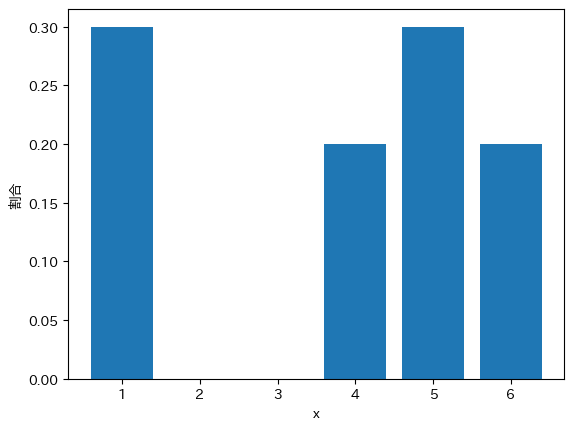

In [7]:
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.bar(element, count / size)
plt.xlabel("x")
plt.ylabel("割合")
plt.show()

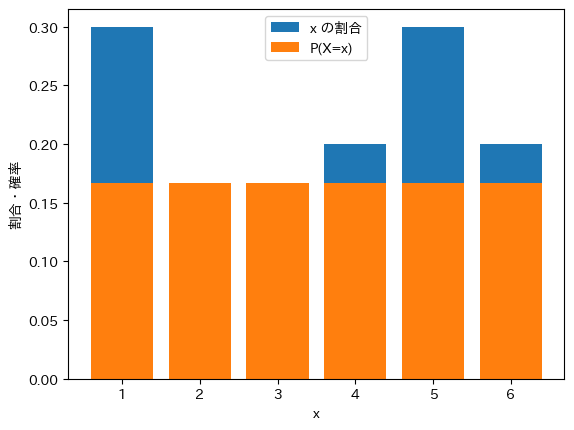

In [8]:
plt.bar(element, count / size, label="x の割合")
plt.bar(X, P, label="P(X=x)")
plt.xlabel("x")
plt.ylabel("割合・確率")
plt.legend()
plt.show()

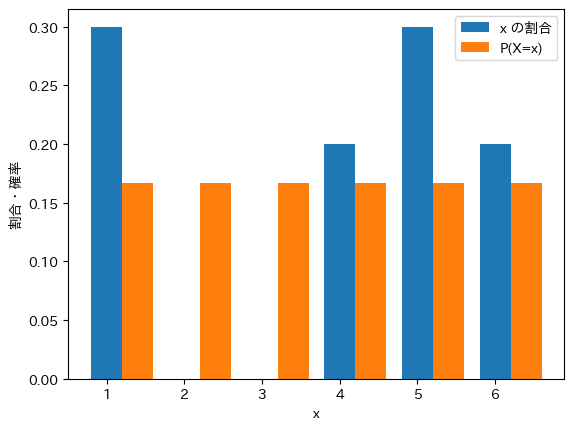

In [9]:
width = 0.4
plt.bar(element, count / size, width=width, label="x の割合")
plt.bar(X + width, P, width=width, label="P(X=x)")
plt.xlabel("x")
plt.ylabel("割合・確率")
plt.legend()
plt.show()

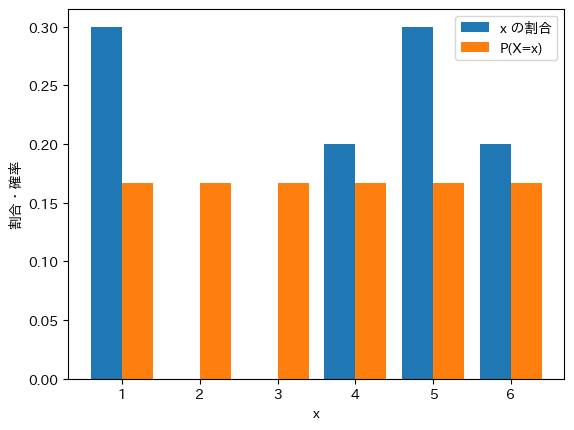

In [10]:
width = 0.4
plt.bar(element - width / 2, count / size, width=width, label="x の割合")
plt.bar(X + width / 2, P, width=width, label="P(X=x)")
plt.xlabel("x")
plt.ylabel("割合・確率")
plt.legend()
plt.show()

In [11]:
def sampling(X, P, size):
    result = {e: 0 for e in X}
    sizeleft = size
    while sizeleft > 0:
        s = min(sizeleft, 1000000)
        sample = np.random.choice(X, p=P, size=s)    
        element, count = np.unique(sample, return_counts=True) 
        for e, c in zip(element, count):
            result[e] += c
        sizeleft -= s
    element = np.array(list(result.keys()))
    count = np.array(list(result.values()))
    return element, count

In [12]:
element, count = sampling(X, P, 10 ** 9)
print(element)
print(count)
print(sum(count))

[1 2 3 4 5 6]
[166671420 166673749 166664171 166670700 166662566 166657394]
1000000000


In [13]:
def sampling(X, P, size):
    result = {e: 0 for e in X}
    sizeleft = size
    while sizeleft > 0:
        s = min(sizeleft, 1000000)
        sample = np.random.choice(X, p=P, size=s)    
        element, count = np.unique(sample, return_counts=True) 
        for e, c in zip(element, count):
            result[e] += c
        sizeleft -= s
    element = np.array(list(result.keys()))
    count = np.array(list(result.values()))
      
    plt.figure(figsize=(4, 3))
    width = 0.4
    plt.bar(element - width / 2, count / size, width=width, label="x の割合")
    plt.bar(X + width / 2 , P, width=width, label="P(X=x)")
    plt.xlabel("x")
    plt.ylabel("割合・確率")
    plt.ylim(0, max(count/size) + 0.07)
    plt.title(f"size = {size}")
    plt.legend()
    plt.show()
    return element, count   

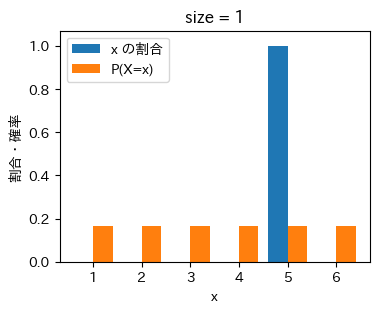

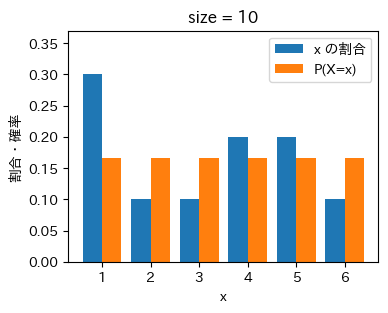

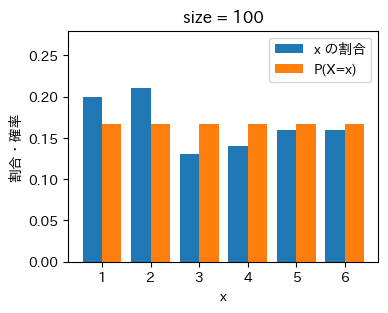

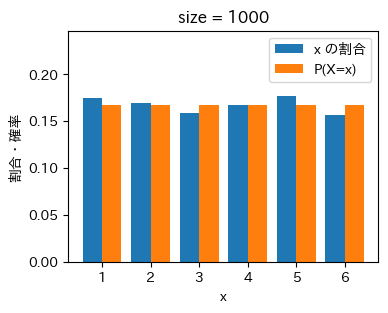

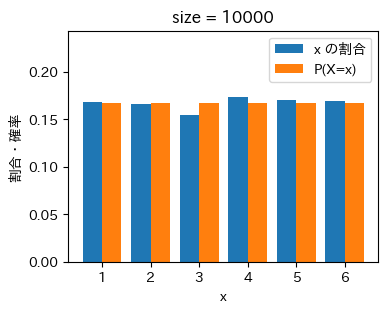

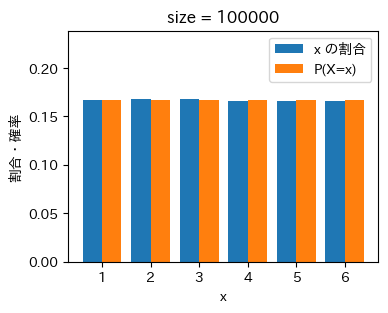

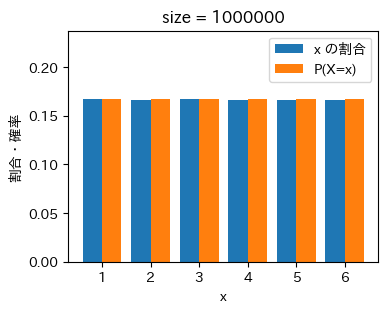

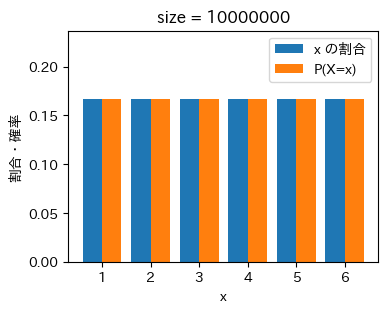

In [14]:
for size in range(8):
    sampling(X, P, 10 ** size)

[0.09855378 0.13992523 0.30101556 0.16594175 0.17671272 0.11785096]
[1 2 3 4 5 6]
0.9999999999999999


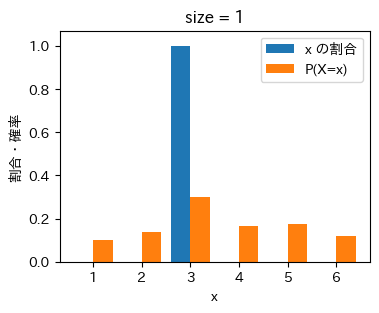

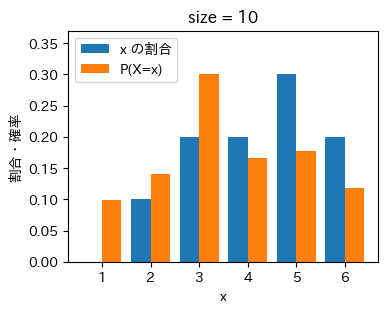

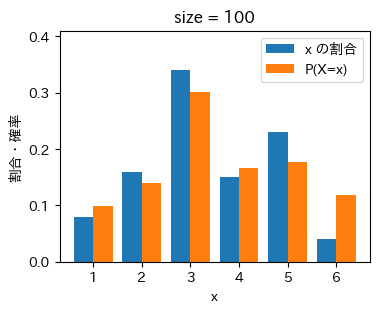

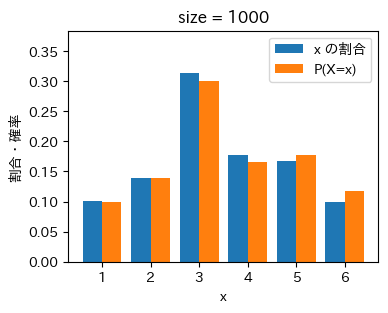

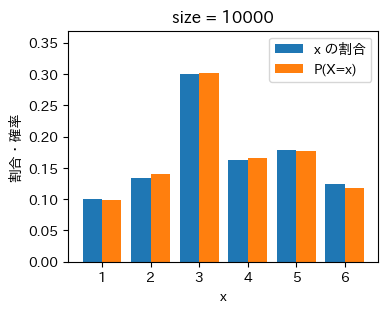

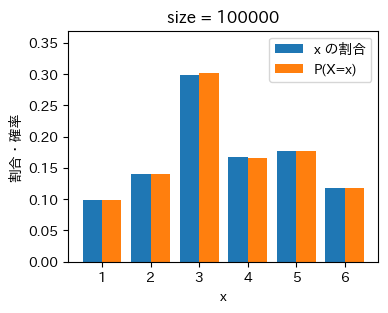

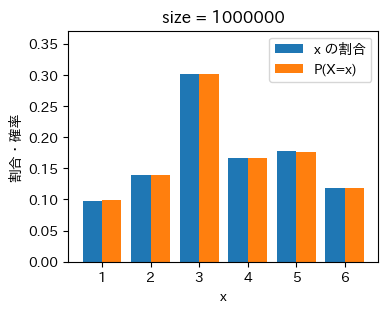

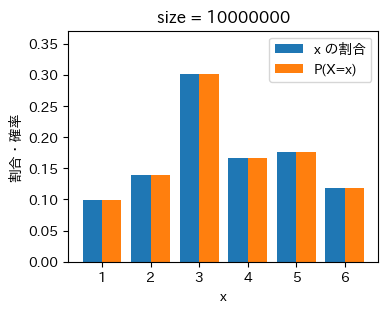

In [ ]:
from util import create_pd

X, P = create_pd(minx=1, maxx=6)
print(P)
print(X)
print(sum(P))
for size in range(8):
    sampling(X, P, 10 ** size)